Title: Seasonal_RL_Analysis.ipynb

Purpose: Analyse the seasonal RL from the ERA5, CMIP6 and importance sampling data

Author: Onno Nennecke on 24.03.2026 Modified: 24.03.2026

Input data: 

- Adjusted Model output: model_output_adj.nc
    - This file lies here: '/climca/people/onennecke/model_output/not_bias_corrected/model_output_all.nc'

Output data:

- Plots: 2D_hist, Return_period_plot
    - These files lie here: /home/onennecke/Code/Figures/

In [ ]:
# Importing libraries
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.ndimage as ndimage
import matplotlib as mpl
from matplotlib.colors import LogNorm
from matplotlib.gridspec import GridSpec
import matplotlib.patches as mpatches

import seaborn as sns

In [39]:
path = '/climca/people/onennecke/model_output/not_bias_corrected/model_output_all.nc'
files = [path]

ds = xr.open_dataset(path)

ds.load()

ts_datasets = ds.where(ds.ESM_run != 'SMARD_hist',drop=True)
ts_datasets.load()

ds_CMIP6 = ds.where((ds.ESM_run != 'ERA5_hist_week') & (ds.ESM_run != 'SMARD_hist'),drop=True)
ds_CMIP6.load()

ds_ERA5 = ds.where(ds.ESM_run == 'ERA5_hist_week',drop=True)
ds_ERA5.load()


<xarray.Dataset> Size: 365kB
Dimensions:        (ESM_run: 1, time: 3650)
Coordinates:
    crs            int64 8B 4326
    gridtype       <U6 24B 'lonlat'
  * time           (time) datetime64[ns] 29kB 2015-01-01 ... 2024-12-31
    ESM            (ESM_run) <U13 52B 'ERA5_week'
    run            (ESM_run) <U12 48B 'hist'
  * ESM_run        (ESM_run) <U23 92B 'ERA5_hist_week'
    country        float64 8B 9.0
    period         (ESM_run) <U4 16B 'week'
    doy            (time) int64 29kB 1 2 3 4 5 6 7 ... 360 361 362 363 364 365
Data variables:
    temp           (ESM_run, time) float64 29kB 1.323 3.335 ... 0.7396 0.4142
    demand         (ESM_run, time) float64 29kB 1.504e+03 ... 1.515e+03
    sfcWind        (ESM_run, time) float64 29kB 7.507 11.86 ... 8.049 8.775
    rsds           (ESM_run, time) float32 15kB 30.54 19.51 17.85 ... 26.3 31.92
    tas            (ESM_run, time) float32 15kB 1.771 3.587 ... 1.512 1.194
    tasmax         (ESM_run, time) float32 15kB 3.431 5.871 ... 2.709 3.361
    wind_off_prod  (ESM_run, time) float64 29kB 220.8 221.2 ... 221.1 221.1
    wind_on_prod   (ESM_run, time) float64 29kB 695.5 1.357e+03 ... 783.9 831.2
    solar_prod     (ESM_run, time) float64 29kB 53.72 25.34 ... 48.64 59.86
    total_prod     (ESM_run, time) float64 29kB 970.0 1.603e+03 ... 1.112e+03
    Netto          (ESM_run, time) float64 29kB -533.6 124.7 ... -457.1 -402.6
    Residual_load  (ESM_run, time) float64 29kB 533.6 -124.7 ... 457.1 402.6

In [16]:
ts_datasets['Residual_load']

<xarray.DataArray 'Residual_load' (ESM_run: 193, time: 3650)> Size: 6MB
array([[ 609.48011372,  793.41464988,  907.1603086 , ..., 1232.37851857,
        1066.37782121,  592.87906948],
       [ 462.58176097,  475.54562743,  537.65952392, ...,  778.522393  ,
         242.01169521,  -92.22855004],
       [ 325.23504813,  867.82497075, 1200.82346924, ..., 1283.62115454,
        1260.91735393,  601.21880191],
       ...,
       [ 888.26090391,  441.74362188,  495.5597482 , ...,  161.56865504,
         287.78453579,  -78.23281115],
       [1278.89246127, 1260.97681835, 1403.45791958, ..., 1212.56949988,
        1300.25157802, 1457.76143367],
       [ 548.54142222, -109.18751349, -210.90010476, ..., 1306.70204962,
        1506.6195729 , 1319.56557544]])
Coordinates:
    crs       int64 8B 4326
    gridtype  <U6 24B 'lonlat'
  * time      (time) datetime64[ns] 29kB 2015-01-01 2015-01-02 ... 2024-12-31
    ESM       (ESM_run) <U13 10kB 'ACCESS-CM2' 'ACCESS-CM2' ... 'UKESM1-0-LL'
    run       (ESM_run) <U12 9kB 'r1i1p1f1' 'r4i1p1f1' ... 'r7i1p1f2' 'r8i1p1f2'
  * ESM_run   (ESM_run) <U23 18kB 'ACCESS-CM2_r1i1p1f1' ... 'UKESM1-0-LL_r8i1...
    country   float64 8B 9.0
    period    (ESM_run) <U4 3kB 'week' 'week' 'week' ... 'week' 'week' 'week'
    doy       (time) int64 29kB 1 2 3 4 5 6 7 8 ... 359 360 361 362 363 364 365

In [46]:
not_winter = np.repeat(0, 183)

season = np.concatenate(
    [np.repeat(1, 90)] +
    [arr
        for i in range(2, 11)
        for arr in (not_winter, np.repeat(i, 182))
    ] +
    [not_winter, np.repeat(11, 92)]
)
print(len(season))

3650


In [49]:
ts_datasets= ts_datasets.assign_coords(season=("time", season))

In [58]:
ts_seasonal_mean = ts_datasets.groupby('season').mean('time')
ts_seasonal_mean = ts_seasonal_mean['Residual_load'][ts_seasonal_mean.season != 0]
ts_seasonal_mean

<xarray.DataArray 'Residual_load' (season: 11, ESM_run: 193)> Size: 17kB
array([[ 759.52527892,  965.91945379,  903.9082295 , ...,  907.75595288,
         768.36683978,  747.6725589 ],
       [ 812.94353059, 1023.50323406,  850.64982925, ...,  894.5187634 ,
         870.20536051,  954.31086079],
       [1005.68398245,  791.66390153,  803.49314819, ...,  880.88680577,
         748.09345956,  854.82304125],
       ...,
       [ 995.82155154,  975.73395731,  898.90106812, ...,  890.56312894,
         841.63603366,  967.64354375],
       [ 878.447398  ,  794.10648491,  930.58944144, ...,  824.93032857,
        1015.54139252,  835.525934  ],
       [ 954.16376765,  887.80546192, 1030.55996265, ...,  930.11451336,
         824.62681217, 1005.44297479]])
Coordinates:
    crs       int64 8B 4326
    gridtype  <U6 24B 'lonlat'
    ESM       (ESM_run) <U13 10kB 'ACCESS-CM2' 'ACCESS-CM2' ... 'UKESM1-0-LL'
    run       (ESM_run) <U12 9kB 'r1i1p1f1' 'r4i1p1f1' ... 'r7i1p1f2' 'r8i1p1f2'
  * ESM_run   (ESM_run) <U23 18kB 'ACCESS-CM2_r1i1p1f1' ... 'UKESM1-0-LL_r8i1...
    country   float64 8B 9.0
    period    (ESM_run) <U4 3kB 'week' 'week' 'week' ... 'week' 'week' 'week'
  * season    (season) int64 88B 1 2 3 4 5 6 7 8 9 10 11

In [68]:
df = ts_seasonal_mean.to_dataframe(name="Residual_load").reset_index()
df

,season,ESM_run,crs,gridtype,ESM,run,country,period,Residual_load
0,1,ACCESS-CM2_r1i1p1f1,4326,lonlat,ACCESS-CM2,r1i1p1f1,9.0,week,759.525279
1,1,ACCESS-CM2_r4i1p1f1,4326,lonlat,ACCESS-CM2,r4i1p1f1,9.0,week,965.919454
2,1,ACCESS-CM2_r5i1p1f1,4326,lonlat,ACCESS-CM2,r5i1p1f1,9.0,week,903.908229
3,1,BCC-CSM2-MR_r1i1p1f1,4326,lonlat,BCC-CSM2-MR,r1i1p1f1,9.0,week,1134.775641
4,1,CESM2_LE2-1001_001,4326,lonlat,CESM2,LE2-1001_001,9.0,week,1034.448522
...,...,...,...,...,...,...,...,...,...
2118,11,UKESM1-0-LL_r4i1p1f2,4326,lonlat,UKESM1-0-LL,r4i1p1f2,9.0,week,1014.129921
2119,11,UKESM1-0-LL_r5i1p1f2,4326,lonlat,UKESM1-0-LL,r5i1p1f2,9.0,week,999.555764
2120,11,UKESM1-0-LL_r6i1p1f2,4326,lonlat,UKESM1-0-LL,r6i1p1f2,9.0,week,930.114513
2121,11,UKESM1-0-LL_r7i1p1f2,4326,lonlat,UKESM1-0-LL,r7i1p1f2,9.0,week,824.626812


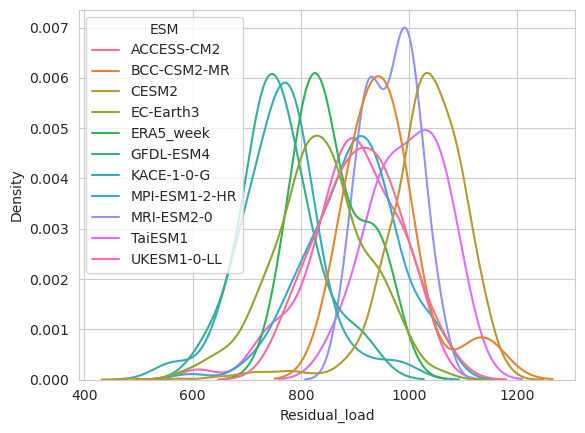

In [69]:
# import seaborn as sns
# import matplotlib.pyplot as plt

plt.figure()
sns.kdeplot(
    data=df,
    x="Residual_load",
    hue="ESM",
    common_norm=False
)

plt.show()

In [70]:
# Flatten: combine all ESM_runs per season if needed
values = ts_seasonal_mean.values.flatten()

# Sort descending
sorted_vals = np.sort(values)[::-1]

# Empirical probability (rank / total)
prob = np.arange(1, len(sorted_vals)+1) / len(sorted_vals)

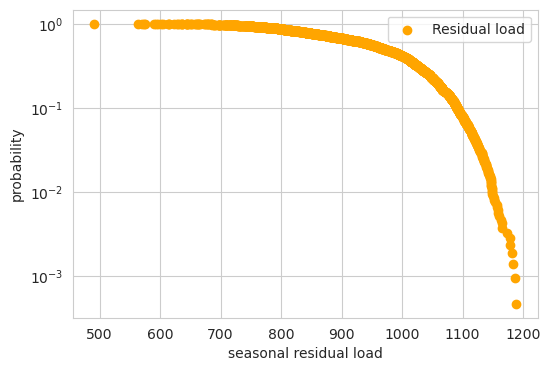

In [71]:
plt.figure(figsize=(6,4))
plt.scatter(sorted_vals, prob, color="orange", label="Residual load")
plt.yscale("log")   # log-scale for probability
plt.xlabel("seasonal residual load")
plt.ylabel("probability")
plt.legend()
plt.show()

In [83]:
# Flatten values but keep track of which ESM they come from
esm_coords = []
values = []

for esm_run in ts_seasonal_mean['ESM_run']:
    for esm_val in ts_seasonal_mean.sel(ESM_run=esm_run).values.flatten():
        values.append(esm_val)
        esm_coords.append(ts_seasonal_mean.sel(ESM_run=esm_run)['ESM'].values.item())

values = np.array(values)
esm_coords = np.array(esm_coords)

# Sort values descending but keep indices to track ESM
sorted_indices = np.argsort(values)[::-1]
sorted_vals = values[sorted_indices]
sorted_esm = esm_coords[sorted_indices]

# Make array of colours for each ESM
unique_esms = np.unique(sorted_esm)
colors = plt.cm.tab10(np.linspace(0, 1, len(unique_esms)))
esm_color_map = {esm: colors[i] for i, esm in enumerate(unique_esms)}
point_colors = [esm_color_map[esm] for esm in sorted_esm]

# Empirical probability
prob = np.arange(1, len(sorted_vals)+1) / len(sorted_vals)

In [85]:
len(point_colors)

2123

/tmp/ipykernel_2055328/4104426604.py:10: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  scatter = plt.scatter(sorted_vals, prob, c=point_colors, cmap='viridis', label="Residual load", marker ='x', s=10)


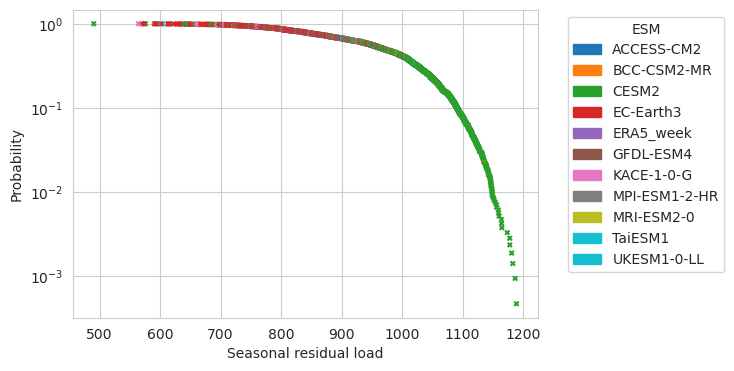

In [ ]:
# Example structure:
# ts_seasonal_mean is a xarray DataArray or pandas DataFrame
# dimensions: ('ESM_run', 'season') or similar
# 'ESM' coordinate exists: ts_seasonal_mean['ESM']


# Plot, coloring by ESM
plt.figure(figsize=(6,4))
scatter = plt.scatter(sorted_vals, prob, c=point_colors, cmap='viridis', label="Residual load", marker ='x', s=10)
plt.yscale("log")
plt.xlabel("Seasonal residual load")
plt.ylabel("Probability")
# Create legend patches for each ESM
patches = [mpatches.Patch(color=esm_color_map[esm], label=esm) for esm in unique_esms]
plt.legend(handles=patches, title="ESM", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

In [78]:
for i, esm in enumerate(np.unique(ts_seasonal_mean.ESM.values)):
    print(f"ESM: {esm}")

ESM: ACCESS-CM2
ESM: BCC-CSM2-MR
ESM: CESM2
ESM: EC-Earth3
ESM: ERA5_week
ESM: GFDL-ESM4
ESM: KACE-1-0-G
ESM: MPI-ESM1-2-HR
ESM: MRI-ESM2-0
ESM: TaiESM1
ESM: UKESM1-0-LL


In [93]:
np.unique(ts_seasonal_mean.ESM.values)

array(['ACCESS-CM2', 'BCC-CSM2-MR', 'CESM2', 'EC-Earth3', 'ERA5_week',
       'GFDL-ESM4', 'KACE-1-0-G', 'MPI-ESM1-2-HR', 'MRI-ESM2-0',
       'TaiESM1', 'UKESM1-0-LL'], dtype='<U13')

In [95]:
np.array(['EC-Earth3'])

array(['EC-Earth3'], dtype='<U9')

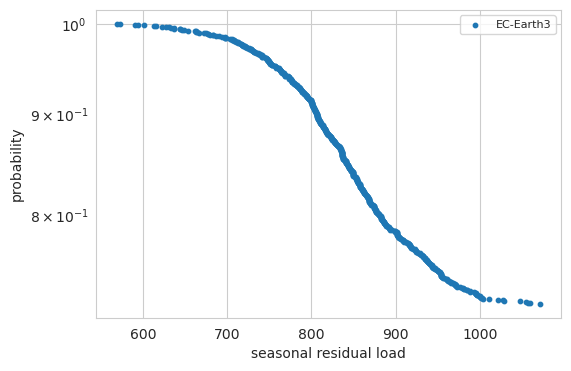

In [96]:
plt.figure(figsize=(6,4))
for esm in np.array(['EC-Earth3']):
# for esm in np.unique(ts_seasonal_mean.ESM.values):

    vals = ts_seasonal_mean.where(ts_seasonal_mean.ESM == esm).values.flatten()
    sorted_vals = np.sort(vals)[::-1]
    prob = np.arange(1, len(sorted_vals)+1) / len(sorted_vals)
    plt.scatter(sorted_vals, prob, label=esm, s=10)  # s=10 for smaller points

plt.yscale("log")
plt.xlabel("seasonal residual load")
plt.ylabel("probability")
plt.legend(ncol=2, fontsize=8)
plt.show()

In [98]:
len(np.unique(ts_seasonal_mean.ESM.values))

11

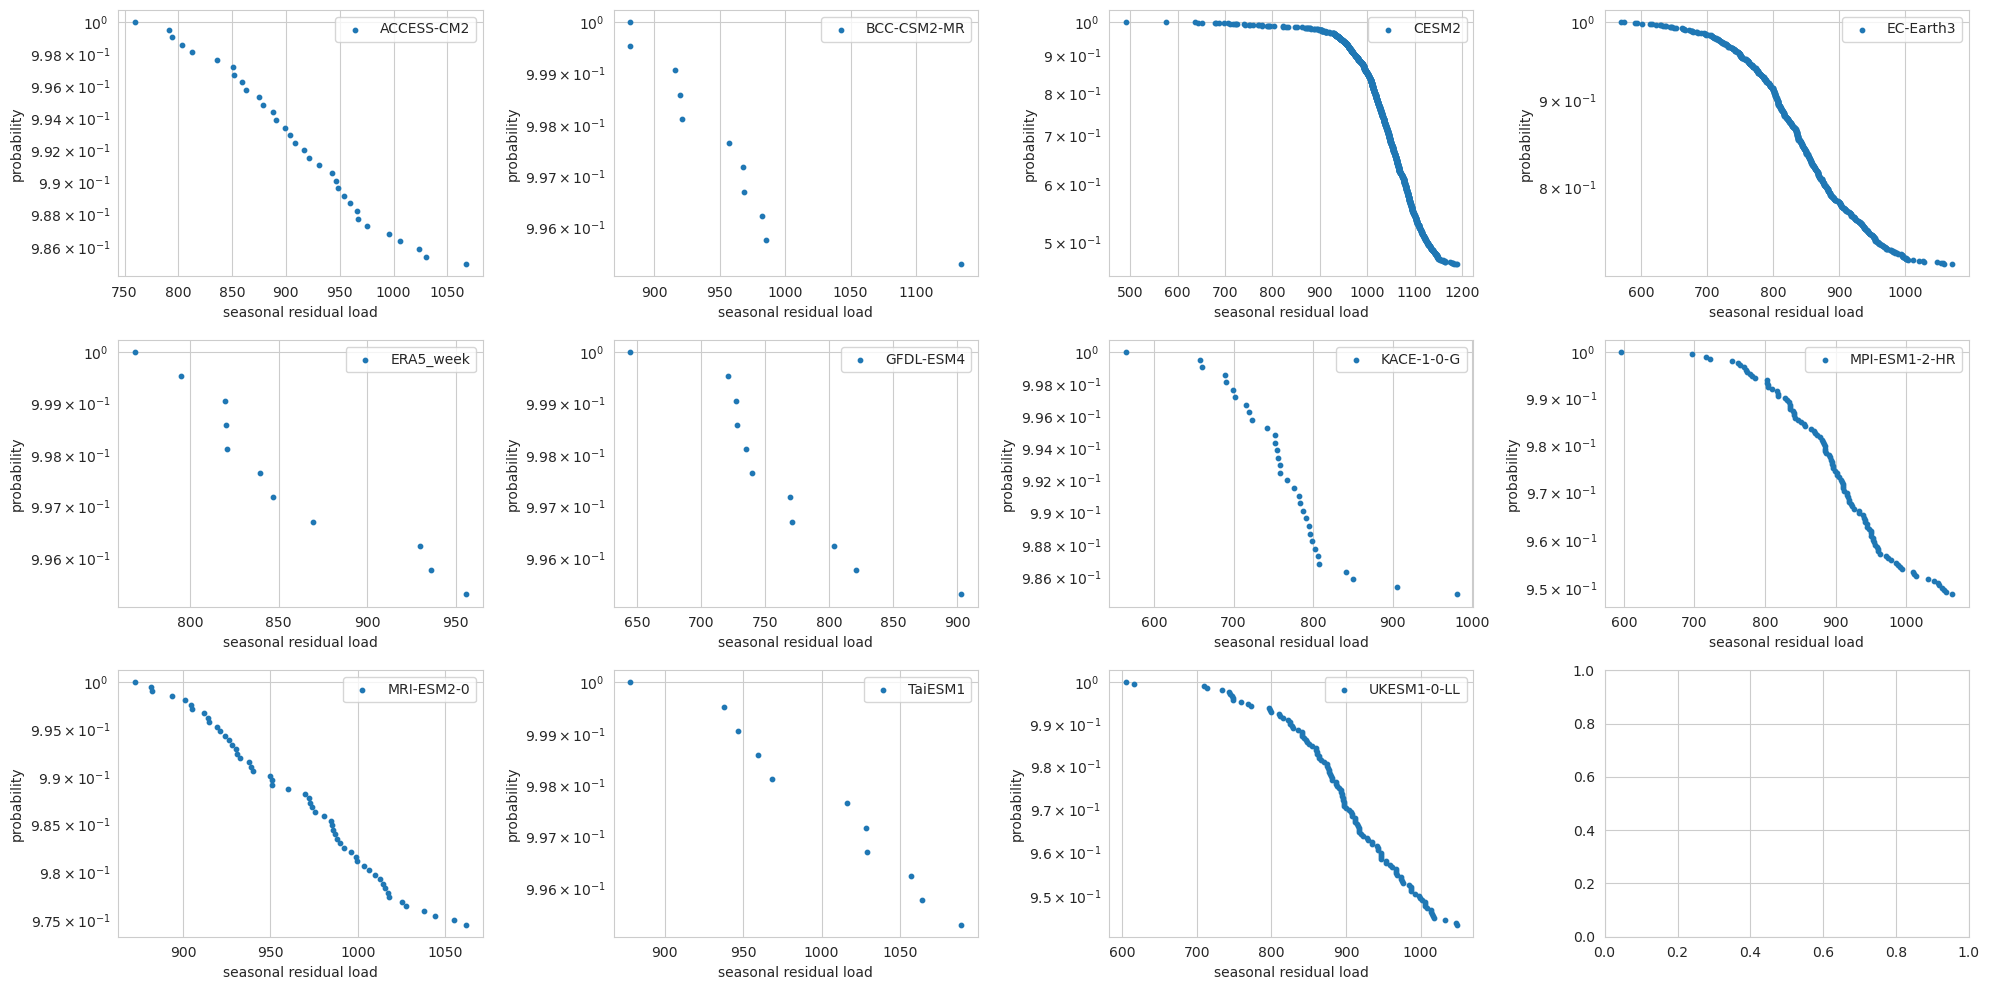

In [101]:
fig, axes = plt.subplots(3, 4, figsize=(20, 10))
for i in range(3):
    for j in range(4):
        idx = i*4 + j
        if idx < len(unique_esms):
            esm = unique_esms[idx]
            vals = ts_seasonal_mean.where(ts_seasonal_mean.ESM == esm).values.flatten()
            sorted_vals = np.sort(vals)[::-1]
            prob = np.arange(1, len(sorted_vals)+1) / len(sorted_vals)
            axes[i, j].scatter(sorted_vals, prob, label=esm, s=10)
            axes[i, j].set_yscale("log")
            axes[i, j].set_xlabel("seasonal residual load")
            axes[i, j].set_ylabel("probability")
            axes[i, j].legend()
plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(6,4))
for esm in np.unique(ts_seasonal_mean.ESM.values):
    vals = ts_seasonal_mean.where(ts_seasonal_mean.ESM == esm).values.flatten()
    sorted_vals = np.sort(vals)[::-1]
    prob = np.arange(1, len(sorted_vals)+1) / len(sorted_vals)
    plt.scatter(sorted_vals, prob, label=esm, s=10)  # s=10 for smaller points

plt.yscale("log")
plt.xlabel("seasonal residual load")
plt.ylabel("probability")
plt.legend(ncol=2, fontsize=8)
plt.show()

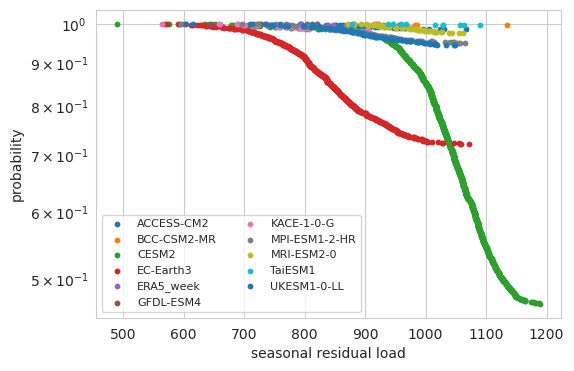

In [97]:
plt.figure(figsize=(6,4))
for esm in np.unique(ts_seasonal_mean.ESM.values):
    vals = ts_seasonal_mean.where(ts_seasonal_mean.ESM == esm).values.flatten()
    sorted_vals = np.sort(vals)[::-1]
    prob = np.arange(1, len(sorted_vals)+1) / len(sorted_vals)
    plt.scatter(sorted_vals, prob, label=esm, s=10)  # s=10 for smaller points

plt.yscale("log")
plt.xlabel("seasonal residual load")
plt.ylabel("probability")
plt.legend(ncol=2, fontsize=8)
plt.show()

In [103]:
5*(10**-1)

0.5